<a href="https://colab.research.google.com/github/anaribeiro4/novo-repositorio/blob/main/Trabalho2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PARTE 1 - ANÁLISE DO PROBLEMA XOR


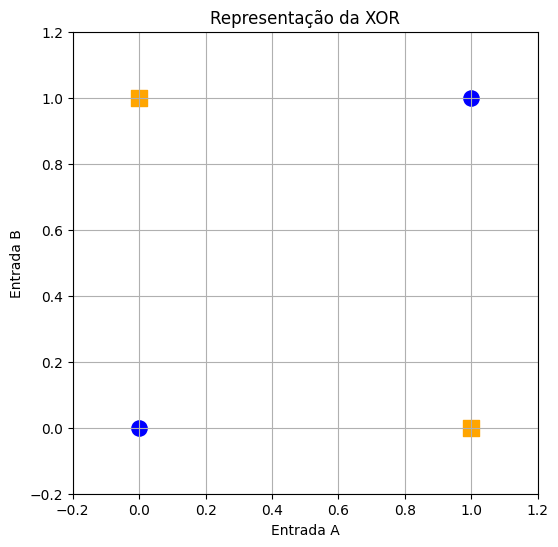



PARTE 3 - FUNÇÕES DE ATIVAÇÃO


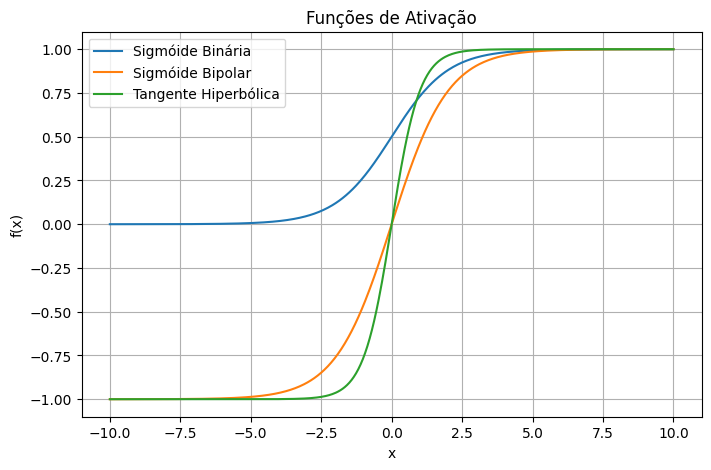



PARTE 4 e 5 - IMPLEMENTAÇÃO DA REDE MLP & BACKPROPAGATION


PARTE 6 - REPRODUÇÃO DO EXPERIMENTO XOR
Épocas até convergência: 8360
Erro Quadrático Final: 0.0009998918086992531

Saídas Finais da Rede:
[0 0] -> 0.028024
[0 1] -> 0.966306
[1 0] -> 0.968974
[1 1] -> 0.033401


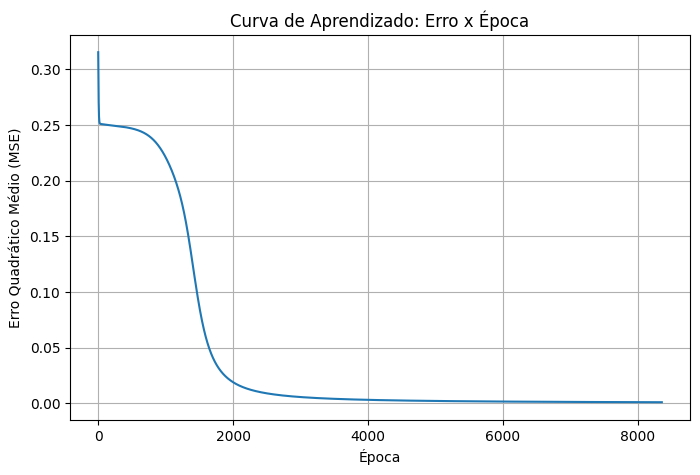



PARTE 7A - EXPERIMENTO A (Neurônios na Camada Oculta)
   Neurônios  Épocas  Erro Final
0          2   10048       0.001
1          3    7981       0.001
2          4    8360       0.001
3          5    9383       0.001


PARTE 7B - EXPERIMENTO B (Taxa de Aprendizagem)
   Taxa  Épocas  Erro Final
0   0.1   16717       0.001
1   0.2    8360       0.001
2   0.3    5574       0.001
3   0.4    4181       0.001
4   0.5    3345       0.001


PARTE 7C - EXPERIMENTO C (Inicialização de Pesos)
   Semente  Épocas  Erro Final
0        0    6920       0.001
1        1    9051       0.001
2        2    8309       0.001
3        3    9280       0.001
4        4    7730       0.001


PARTE 8 - ANÁLISE DOS RESULTADOS
Melhor quantidade de neurônios: 3
Melhor taxa de aprendizagem: 0.5
Melhor semente de inicialização: 0


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("=" * 60)
print("PARTE 1 - ANÁLISE DO PROBLEMA XOR")
print("=" * 60)

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([
    [0],
    [1],
    [1],
    [0]
])

plt.figure(figsize=(6, 6))
for i in range(len(X)):
    if y[i] == 0:
        plt.scatter(X[i, 0], X[i, 1], marker='o', s=120, color='blue')
    else:
        plt.scatter(X[i, 0], X[i, 1], marker='s', s=120, color='orange')

plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.xlabel("Entrada A")
plt.ylabel("Entrada B")
plt.title("Representação da XOR")
plt.grid(True)
plt.show()

print("\n")
print("=" * 60)
print("PARTE 3 - FUNÇÕES DE ATIVAÇÃO")
print("=" * 60)

def sigmoide(x):
    return 1 / (1 + np.exp(-x))

def dsigmoide(y):
    return y * (1 - y)

def sigmoide_bipolar(x):
    return (2 / (1 + np.exp(-x))) - 1

def tangente_hiperbolica(x):
    return np.tanh(x)

x_func = np.linspace(-10, 10, 500)

plt.figure(figsize=(8, 5))
plt.plot(x_func, sigmoide(x_func), label="Sigmóide Binária")
plt.plot(x_func, sigmoide_bipolar(x_func), label="Sigmóide Bipolar")
plt.plot(x_func, tangente_hiperbolica(x_func), label="Tangente Hiperbólica")
plt.title("Funções de Ativação")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()

print("\n")
print("=" * 60)
print("PARTE 4 e 5 - IMPLEMENTAÇÃO DA REDE MLP & BACKPROPAGATION")
print("=" * 60)

class MLP:
    def __init__(self, entradas, ocultos, saidas, taxa):
        self.taxa = taxa
        self.w1 = np.random.uniform(-1, 1, (entradas, ocultos))
        self.b1 = np.random.uniform(-1, 1, (1, ocultos))
        self.w2 = np.random.uniform(-1, 1, (ocultos, saidas))
        self.b2 = np.random.uniform(-1, 1, (1, saidas))

    def forward(self, X):
        self.z1 = np.dot(X, self.w1) + self.b1
        self.a1 = sigmoide(self.z1)
        self.z2 = np.dot(self.a1, self.w2) + self.b2
        self.a2 = sigmoide(self.z2)
        return self.a2

    def backward(self, X, y):
        erro_saida = y - self.a2
        delta_saida = erro_saida * dsigmoide(self.a2)

        erro_oculta = np.dot(delta_saida, self.w2.T)
        delta_oculta = erro_oculta * dsigmoide(self.a1)

        self.w2 += self.taxa * np.dot(self.a1.T, delta_saida)
        self.b2 += self.taxa * np.sum(delta_saida, axis=0, keepdims=True)
        self.w1 += self.taxa * np.dot(X.T, delta_oculta)
        self.b1 += self.taxa * np.sum(delta_oculta, axis=0, keepdims=True)

        # Alterado para Erro Quadrático Médio (MSE) para seguir o padrão clássico
        return np.mean(np.square(erro_saida))

    def treinar(self, X, y, tolerancia=0.001, max_epocas=50000):
        erros = []
        for epoca in range(max_epocas):
            self.forward(X)
            erro = self.backward(X, y)
            erros.append(erro)
            if erro < tolerancia:
                return epoca + 1, erros
        return max_epocas, erros

    def prever(self, X):
        return self.forward(X)

np.random.seed(42)
rede = MLP(entradas=2, ocultos=4, saidas=1, taxa=0.2)

print("\n")
print("=" * 60)
print("PARTE 6 - REPRODUÇÃO DO EXPERIMENTO XOR")
print("=" * 60)

epocas, erros = rede.treinar(X, y, tolerancia=0.001)
print("Épocas até convergência:", epocas)
print("Erro Quadrático Final:", erros[-1])

saida = rede.prever(X)
print("\nSaídas Finais da Rede:")
for entrada, valor in zip(X, saida):
    print(f"{entrada} -> {valor[0]:.6f}")

plt.figure(figsize=(8, 5))
plt.plot(erros)
plt.title("Curva de Aprendizado: Erro x Época")
plt.xlabel("Época")
plt.ylabel("Erro Quadrático Médio (MSE)")
plt.grid(True)
plt.show()

print("\n")
print("=" * 60)
print("PARTE 7A - EXPERIMENTO A (Neurônios na Camada Oculta)")
print("=" * 60)

resultado_a = []
for neuronios in [2, 3, 4, 5]:
    np.random.seed(42)
    rede = MLP(entradas=2, ocultos=neuronios, saidas=1, taxa=0.2)
    epocas, erros = rede.treinar(X, y, tolerancia=0.001)
    resultado_a.append([neuronios, epocas, erros[-1]])

tabela_a = pd.DataFrame(resultado_a, columns=["Neurônios", "Épocas", "Erro Final"])
print(tabela_a)

print("\n")
print("=" * 60)
print("PARTE 7B - EXPERIMENTO B (Taxa de Aprendizagem)")
print("=" * 60)

resultado_b = []
for taxa in [0.1, 0.2, 0.3, 0.4, 0.5]:
    np.random.seed(42)
    rede = MLP(entradas=2, ocultos=4, saidas=1, taxa=taxa)
    epocas, erros = rede.treinar(X, y, tolerancia=0.001)
    resultado_b.append([taxa, epocas, erros[-1]])

tabela_b = pd.DataFrame(resultado_b, columns=["Taxa", "Épocas", "Erro Final"])
print(tabela_b)

print("\n")
print("=" * 60)
print("PARTE 7C - EXPERIMENTO C (Inicialização de Pesos)")
print("=" * 60)

resultado_c = []
for semente in [0, 1, 2, 3, 4]:
    np.random.seed(semente)
    rede = MLP(entradas=2, ocultos=4, saidas=1, taxa=0.2)
    epocas, erros = rede.treinar(X, y, tolerancia=0.001)
    resultado_c.append([semente, epocas, erros[-1]])

tabela_c = pd.DataFrame(resultado_c, columns=["Semente", "Épocas", "Erro Final"])
print(tabela_c)

print("\n")
print("=" * 60)
print("PARTE 8 - ANÁLISE DOS RESULTADOS")
print("=" * 60)

melhor_a = tabela_a.loc[tabela_a["Épocas"].idxmin()]
melhor_b = tabela_b.loc[tabela_b["Épocas"].idxmin()]
melhor_c = tabela_c.loc[tabela_c["Épocas"].idxmin()]

print("Melhor quantidade de neurônios:", int(melhor_a["Neurônios"]))
print("Melhor taxa de aprendizagem:", melhor_b["Taxa"])
print("Melhor semente de inicialização:", int(melhor_c["Semente"]))